# Banking Fraud & Risk Analytics Platform

## Importing All Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

%matplotlib inline

# Section 1: Data Overview

## Loading the Dataset

In [2]:
transactions = pd.read_csv("../data/processed/cleaned_transaction.csv")

accounts = pd.read_csv("../data/processed/cleaned_accounts.csv")

In [3]:
#Changing the dtype
transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

## Creating the copies of dataset

In [4]:
transactions_eda = transactions.copy()

accounts_eda = accounts.copy()

## Dataset Overview

Before beginning the exploratory analysis, the datasets are loaded and inspected to understand their structure, dimensions, data types, and overall characteristics.

## Dataset Shape

In [5]:
print("Transactions Shape :", transactions_eda.shape)

print("Accounts Shape :", accounts_eda.shape)

Transactions Shape : (5078336, 11)
Accounts Shape : (518581, 5)


In [6]:
#Dataset information
transactions_eda.info()
print("--"*50)
accounts_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078336 entries, 0 to 5078335
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[us]
 1   from_bank           int64         
 2   sender_account      str           
 3   to_bank             int64         
 4   receiver_account    str           
 5   amount_received     float64       
 6   receiving_currency  str           
 7   amount_paid         float64       
 8   payment_currency    str           
 9   payment_format      str           
 10  is_laundering       int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 426.2 MB
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   bank_n

In [7]:
#Statistical Summary
transactions_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,5078336,2022-09-05 07:16:07.855403,2022-09-01 00:00:00,2022-09-02 04:32:00,2022-09-05 12:16:00,2022-09-08 03:13:00,2022-09-18 16:18:00,NaN
from_bank,5078336.0,45730.583254,1.0,119.0,9679.0,28628.0,356303.0,81765.6744
to_bank,5078336.0,65744.609435,1.0,4259.0,21568.0,122332.0,356294.0,84093.026783
amount_received,5078336.0,5988736.683497,0.000001,183.37,1411.04,12346.3,1046302363293.47998,1037184027.926735
amount_paid,5078336.0,4509281.359229,0.000001,184.48,1414.57,12298.15,1046302363293.47998,869773601.619475
is_laundering,5078336.0,0.001019,0.0,0.0,0.0,0.0,1.0,0.031912


In [8]:
accounts_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
bank_id,518581.0,103425.510831,121479.549761,1.0,11107.0,32014.0,217096.0,356303.0


In [9]:
#Missing Values
transactions_eda.isnull().sum()

timestamp             0
from_bank             0
sender_account        0
to_bank               0
receiver_account      0
amount_received       0
receiving_currency    0
amount_paid           0
payment_currency      0
payment_format        0
is_laundering         0
dtype: int64

In [10]:
#Missing Values
accounts_eda.isnull().sum()

bank_name         0
bank_id           0
account_number    0
entity_id         0
entity_name       0
dtype: int64

In [11]:
#Duplicate Values
transactions_eda.duplicated().sum()

np.int64(0)

In [12]:
#Duplicate Values
accounts_eda.duplicated().sum()

np.int64(0)

## Initial Observations

- The Transactions dataset contains over **5 million** financial transactions.
- The Accounts dataset contains over **500 thousand** customer accounts.
- No missing values were detected.
- Duplicate transaction records were removed during the data cleaning phase.
- The datasets are ready for exploratory analysis.

# Section 2: Univariate Analysis

## Objective

The objective of univariate analysis is to examine each variable independently to understand its distribution, frequency, variability, and overall characteristics. This analysis provides a foundational understanding of the banking transactions and account datasets before exploring relationships between multiple variables.

The analysis focuses on:

- Understanding the distribution of categorical variables such as payment methods, currencies, banks, and entity types.
- Examining numerical variables to identify central tendencies, variability, and potential outliers.
- Detecting unusual patterns that may indicate data quality issues or suspicious financial activities.
- Identifying dominant categories and transaction characteristics that influence overall banking operations.
- Establishing a baseline understanding of the data to support subsequent bivariate, multivariate, and fraud-specific analyses.

#### Plot of distribution of payment method 

In [ ]:

payment_counts = (
    transactions_eda["payment_format"]
    .value_counts()
    .reset_index()
)

payment_counts.columns = [
    "Payment Method",
    "Transactions"
]

fig = px.bar(
    payment_counts,
    x="Transactions",
    y="Payment Method",
    orientation="h",
    text="Transactions",
    title="Distribution of Payment Methods",
    color_discrete_sequence=["#1F4E79"]
)




fig.update_layout(

    template="plotly_white",height=550,bargap=0.30,
    title_x=0.5,xaxis_title="Number of Transactions",yaxis_title="Payment Method",showlegend=False
    )
fig.update_xaxes(
    showgrid=False
)
fig.show()

### Observation

- **Cheque** is the most frequently used payment method, accounting for **1,864,331 transactions (36.71%)** of the total transaction volume.
- **Credit Card** is the second most common payment method with **1,323,324 transactions (26.06%)**.
- Together, **Cheque and Credit Card account for nearly 63% of all transactions**, indicating that the majority of financial activity is concentrated within these two payment channels.
- **ACH (600,793 transactions)**, **Cash (490,891 transactions)**, and **Reinvestment (481,056 transactions)** represent a moderate share of transaction activity.
- **Wire (171,855 transactions)** and **Bitcoin (146,086 transactions)** are the least frequently used payment methods, contributing only a small proportion of the overall transaction volume.

#### Plot of distribution of payment currency

In [35]:
currency = (
    transactions_eda["payment_currency"]
    .value_counts()
    .reset_index()
)

currency.columns = ["Currency","Transactions"]

fig = px.bar(
    currency,
    x="Transactions",
    y="Currency",
    orientation="h",
    text_auto=True,
    title="Payment Currency Distribution",
    color_discrete_sequence=["#791F51"]
)

fig.update_layout(template="plotly_white",margin=dict(l=180, r=40, t=70, b=50))

fig.show()

### Observation

- **US Dollar** is the most frequently used payment currency, accounting for **1,895,169 transactions (37.32%)**.
- **Euro** is the second most commonly used currency with **1,168,296 transactions (23.01%)**.
- Together, **US Dollar and Euro account for approximately 60% of all payment transactions**, indicating that the majority of financial activity is concentrated in these two currencies.
- Mid-frequency currencies such as **Swiss Franc, Yuan, Shekel, Rupee, and UK Pound** contribute a moderate share of transaction volume.
- **Brazil Real, Saudi Riyal, Mexican Peso, Australian Dollar, and Canadian Dollar** represent the smallest transaction volumes within the dataset.

#### Distribution plot for Laundering or Legitimate

C:\Users\himan\AppData\Local\Temp\ipykernel_20960\1375845223.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


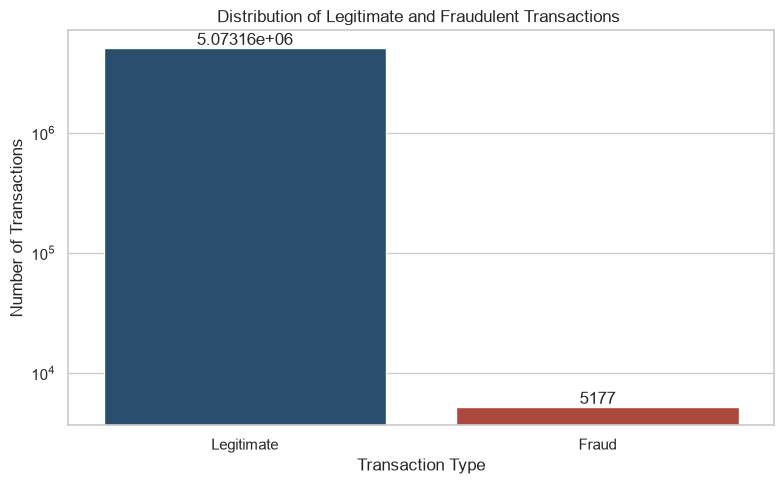

In [43]:
transactions_eda["Transaction Type"] = transactions_eda["is_laundering"].map({
    0: "Legitimate",
    1: "Fraud"
})


plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=transactions_eda,
    x="Transaction Type",
    palette=["#1F4E79", "#C0392B"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.yscale("log")

plt.title("Distribution of Legitimate and Fraudulent Transactions ")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Observation

- The dataset contains **5,073,159 legitimate transactions** and **5,177 fraudulent transactions**.
- Fraudulent transactions account for only **0.10%** of the total **5,078,336** transactions, while legitimate transactions represent **99.90%**.
- A logarithmic scale has been applied to the y-axis to effectively visualize the substantial difference in transaction counts between the two classes.
- The visualization highlights the severe class imbalance, with legitimate transactions exceeding fraudulent transactions by approximately **980:1**.

#### Receiving Currency Plot

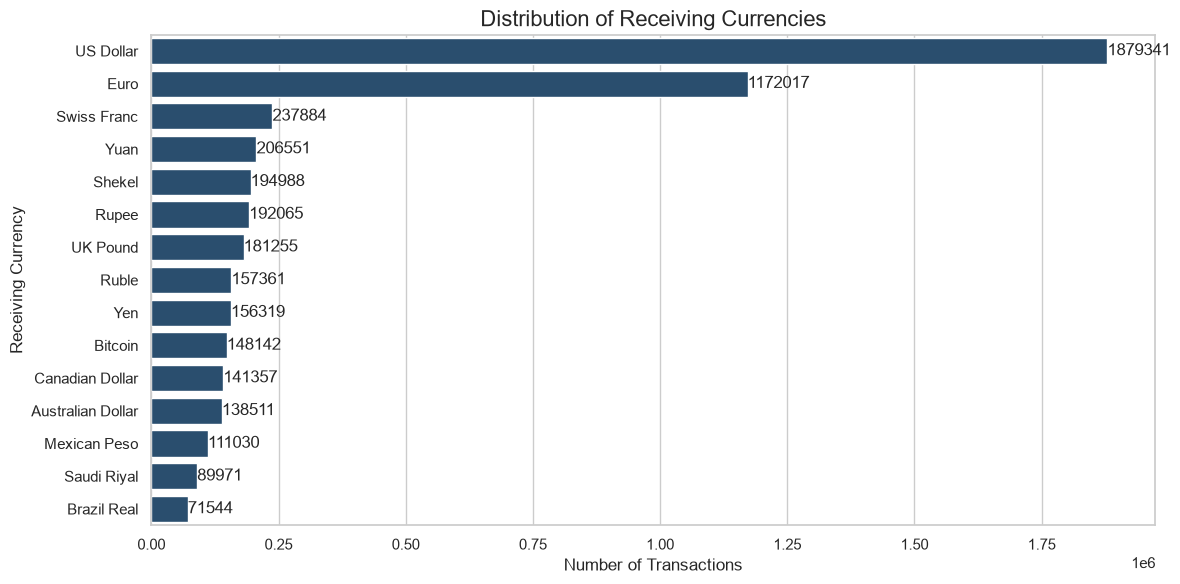

In [44]:
plt.figure(figsize=(12,6))

currency = (
    transactions_eda["receiving_currency"]
    .value_counts()
)

ax = sns.barplot(
    x=currency.values,
    y=currency.index,
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Distribution of Receiving Currencies", fontsize=16)
plt.xlabel("Number of Transactions")
plt.ylabel("Receiving Currency")

plt.tight_layout()
plt.show()

### Observation

- The dataset supports transactions across **15 different receiving currencies**, indicating a globally diversified banking network.
- **US Dollar** is the most frequently received currency with approximately **1.88 million** transactions, accounting for nearly **37%** of all incoming transactions.
- **Euro** is the second most common receiving currency with around **1.17 million** transactions.
- After the top two currencies, transaction frequencies decline significantly, with all remaining currencies individually contributing less than **250,000** transactions.
- Less frequently used currencies such as **Brazil Real** and **Saudi Riyal** represent niche transaction volumes within the dataset.

#### Top Bank by Number of Accounts 

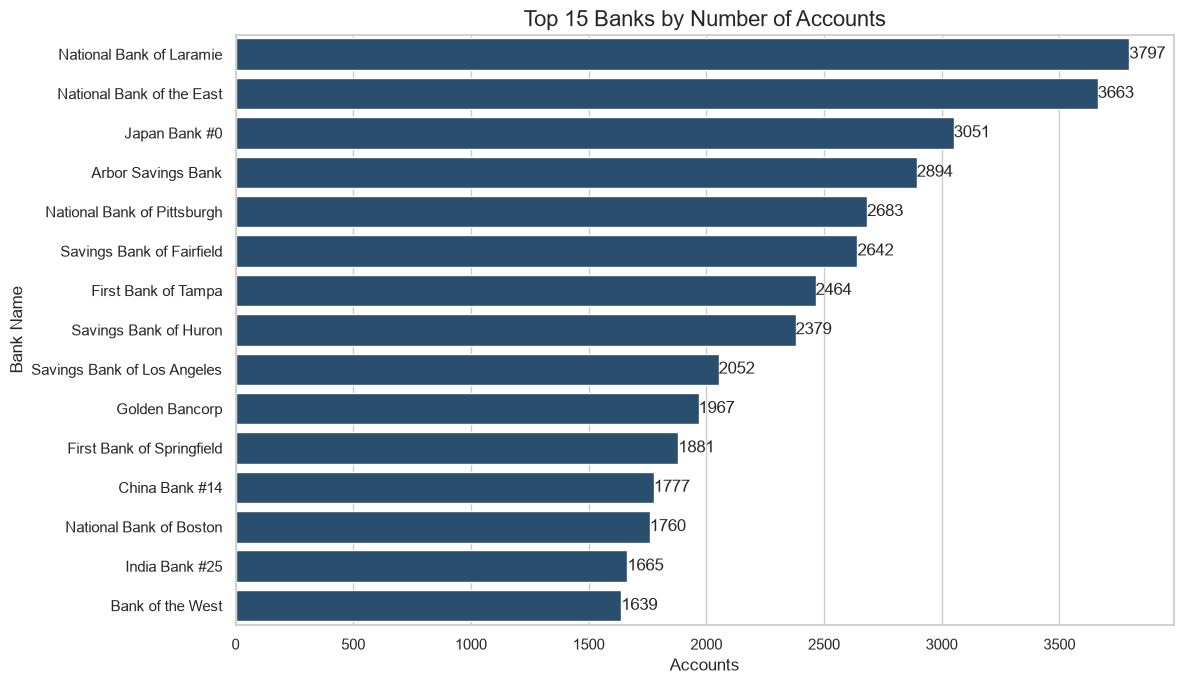

In [45]:
top_bank = (
    accounts_eda["bank_name"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_bank.values,
    y=top_bank.index,
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 15 Banks by Number of Accounts", fontsize=16)
plt.xlabel("Accounts")
plt.ylabel("Bank Name")

plt.tight_layout()
plt.show()

### Observation

- The dataset contains more than **20,000 unique banks**, demonstrating a highly distributed banking ecosystem.
- **National Bank of Laramie** maintains the largest customer base with **3,797 accounts**, followed by **National Bank of the East** with **3,663 accounts**.
- The top fifteen banks have account counts ranging from approximately **1,600 to 3,800**, indicating that customer accounts are relatively well distributed rather than being concentrated within a few institutions.
- No single bank overwhelmingly dominates the account distribution, suggesting a balanced representation across participating financial institutions.

#### Plot of Distribution of Entity Type

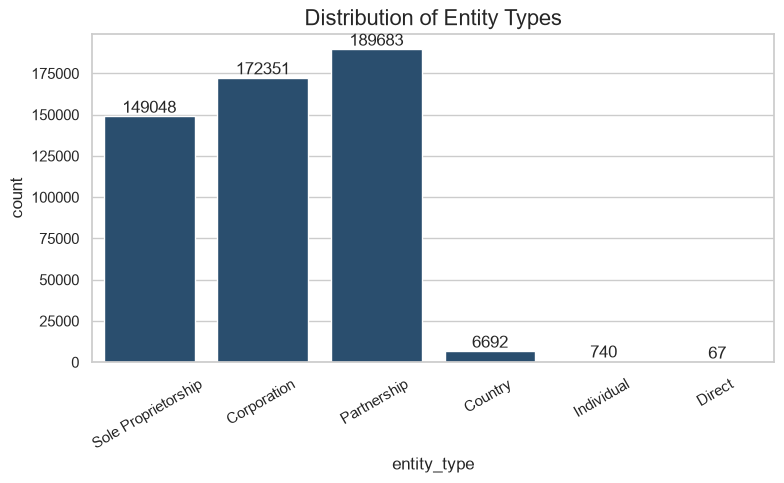

In [46]:
accounts_eda["entity_type"] = (
    accounts_eda["entity_name"]
    .str.split("#")
    .str[0]
)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=accounts_eda,
    x="entity_type",
    color="#1F4E79"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=30)

plt.title("Distribution of Entity Types", fontsize=16)

plt.tight_layout()

plt.show()

### Observation

- The dataset primarily consists of **Partnerships (189,683)**, **Corporations (172,351)**, and **Sole Proprietorships (149,048)**.
- These three business entity categories account for the overwhelming majority of customer accounts.
- Individual accounts are extremely limited (**740 accounts**), while **Direct** entities are nearly absent (**67 accounts**).
- County organizations also represent a relatively small portion of the dataset.

#### BoxPlot for Transaction Amount

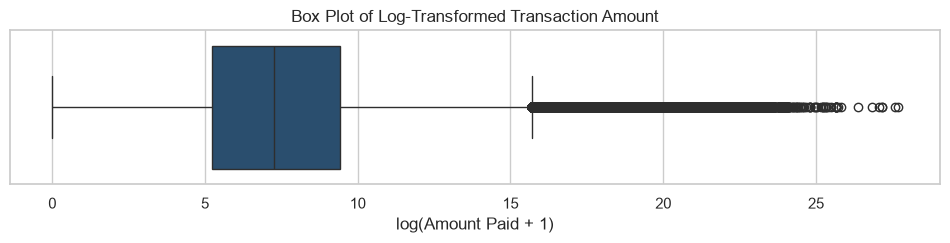

In [48]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=np.log1p(transactions_eda["amount_paid"]),
    color="#1F4E79"
)

plt.title("Box Plot of Log-Transformed Transaction Amount")

plt.xlabel("log(Amount Paid + 1)")

plt.show()

### Observation

- Log transformation significantly improves the visualization of transaction amounts by reducing the impact of extremely large values.
- Most transaction amounts fall within a relatively compact range after transformation.
- A considerable number of high-value outliers remain visible even after applying the logarithmic transformation.
- The presence of these extreme observations indicates that the dataset contains several unusually large financial transactions.

#### Violion Plot for amount distribution

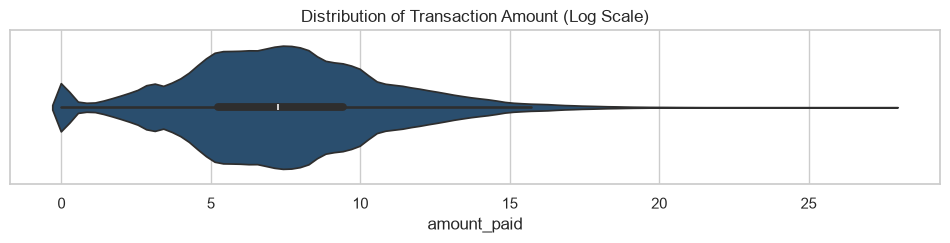

In [49]:
plt.figure(figsize=(12,2))

sns.violinplot(
    x=np.log1p(transactions_eda["amount_paid"]),
    color="#1F4E79"
)

plt.title("Distribution of Transaction Amount (Log Scale)")

plt.show()

### Observation

- The highest density of transactions is concentrated around the middle transaction values after log transformation.
- The distribution exhibits a long right tail, confirming that a relatively small number of transactions involve exceptionally large amounts.
- The median lies near the center of the dense region, while transaction frequencies gradually decrease as transaction amounts increase.
- Overall, transaction amounts remain positively skewed even after logarithmic transformation.

#### Plot of share of payment format

In [50]:
payment = (
    transactions_eda["payment_format"]
    .value_counts()
    .reset_index()
)

payment.columns = ["Payment Method", "Transactions"]

fig = px.pie(
    payment,
    values="Transactions",
    names="Payment Method",
    hole=0.55,
    title="Share of Payment Methods"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()

### Observation

- **Cheque** is the most frequently used payment method, accounting for approximately **36.7%** of all transactions.
- **Credit Card** transactions represent approximately **26.1%**, making it the second most common payment channel.
- **ACH**, **Cash**, and **Reinvestment** each contribute between **9% and 12%** of total transactions.
- **Wire transfers** and **Bitcoin** represent the smallest transaction shares, together accounting for less than **7%** of all transactions.
- Payment activity is concentrated among traditional financial instruments rather than digital assets.

# Section 3: Bivariate Analysis

## Objective

The objective of bivariate analysis is to examine the relationship between two variables in order to identify patterns, dependencies, and potential fraud indicators. Unlike univariate analysis, which focuses on a single feature, bivariate analysis helps uncover how transaction characteristics influence one another and whether specific attributes are associated with suspicious financial activities.

The analysis aims to:

- Identify relationships between payment methods and fraudulent transactions.
- Compare transaction amounts across different payment channels and currencies.
- Examine how transaction patterns vary across banks and entity types.
- Discover business insights that support fraud detection and risk assessment.